<a href="https://colab.research.google.com/github/julianvanegas/DB-Structure/blob/main/Quad_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de logística con Árbol $2^{k \ \text{dimensiones}}$ o Quad Tree

Por Julian Vanegas López (julian.vanegasl@udea.edu.co)

**Problema:** Tenemos $10,000$ puntos de entrega en una ciudad y necesitamos saber ¿cuál es el punto de entrega más cercano a una ubicación dada? y ¿qué puntos de entrega están a un radio determinado de un punto dado?

**Estrategia:** Implementar un Árbol $2^{k \ \text{dimensiones}}$, que para nuestro caso será un Quad Tree o $2^2$ y compararlo contra fuerza bruta utilizando listas.

## Librerías

In [62]:
from typing import Optional, List, Tuple, Any
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import numpy as np
import random
import time

## Generación de datos

Generamos $10.000$ puntos de entrega con coordenadas cartesianas (en metros) dentro del intervalo $[-15000, 15000]$ en ambos ejes.

In [63]:
N_POINTS = 10000 # Cantidad de puntos de entrega

zones = [
    {"centro": (0, 0),         "std": (3000, 2500), "peso": 0.25},  # Centro
    {"centro": (3000, 8000),   "std": (2500, 2000), "peso": 0.15},  # Norte
    {"centro": (-2000, -8000), "std": (3500, 2500), "peso": 0.20},  # Sur
    {"centro": (5000, -4000),  "std": (2000, 3500), "peso": 0.18},  # Oriente
    {"centro": (-5000, 4000),  "std": (2000, 2500), "peso": 0.22},  # Occidente
    ]

delivery_points = []
for zone in zones:
  z = int(N_POINTS * zone["peso"])
  cx, cy = zone["centro"]
  sx, sy = zone["std"]
  xs = np.random.normal(cx, sx, z)
  ys = np.random.normal(cy, sy, z)
  delivery_points.append(np.column_stack([xs, ys]))

# Ajustamos para tener exactamente N_POINTS
delivery_points = np.vstack(delivery_points)[:N_POINTS]

print(f"{len(delivery_points):,} puntos de entrega generados")
print(f"X: [{delivery_points[:,0].min():.0f}m, {delivery_points[:,0].max():.0f}m]")
print(f"Y: [{delivery_points[:,1].min():.0f}m, {delivery_points[:,1].max():.0f}m]")
print(f"Tipo: {delivery_points.dtype}")

10,000 puntos de entrega generados
X: [-14030m, 11769m]
Y: [-16350m, 14897m]
Tipo: float64


### Visualización de todos los puntos de entrega

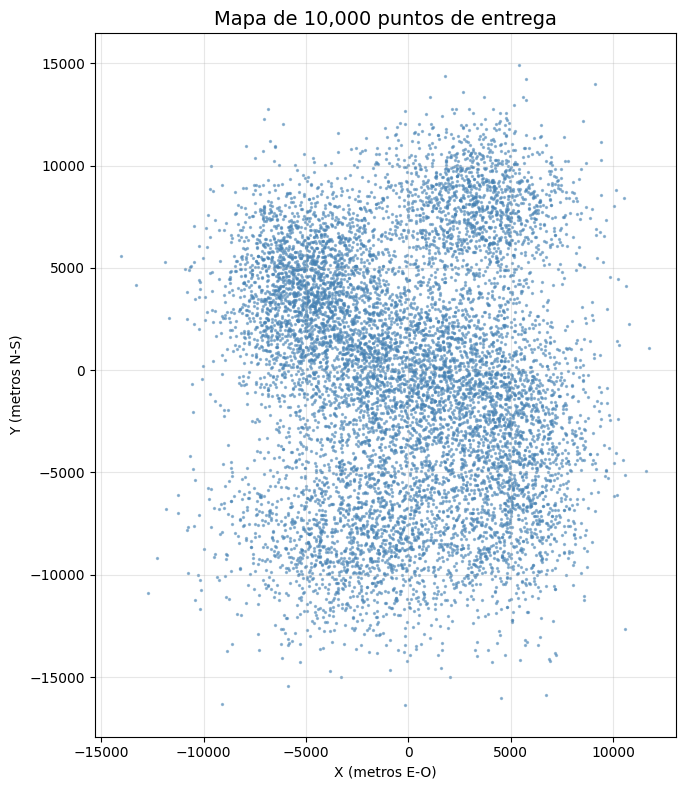

In [64]:
# Visualización de los puntos de entrega
fig, ax = plt.subplots(figsize=(8, 8))

# Todos los puntos de entrega
ax.scatter(delivery_points[:, 0], delivery_points[:, 1], s=2, alpha=0.5, color='steelblue', label='Puntos de entrega')

ax.set_title(f'Mapa de {N_POINTS:,} puntos de entrega', fontsize=14)
ax.set_xlabel('X (metros E-O)')
ax.set_ylabel('Y (metros N-S)')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Árbol $2^{k \ \text{dimensiones}}$ o Quad Tree

El árbol organiza los puntos de forma jerárquica mediante la partición sucesiva del espacio en la mitad geométrica para cada dimensión.

In [65]:
class QuadNode:
  """
  Nodo del árbol 2^K dimensiones.

  Atributos:
    bounds_min: esquina mínima del hiperrectángulo
    bounds_max: esquina máxima del hiperrectángulo
    points: lista de coordenadas, índice original (solo en hojas)
    children: lista de 2^K hijos
  """
  def __init__(self, bounds_min: np.ndarray, bounds_max: np.ndarray):
    self.bounds_min = bounds_min
    self.bounds_max = bounds_max
    self.center = (self.bounds_min + self.bounds_max) / 2
    self.points: np.ndarray = []
    self.children: Optional['QuadNode'] = [] # Si está vacío es una hoja

  def is_leaf(self):
    return len(self.children) == 0


In [66]:
class QuadTree:

  def __init__(self, bounds_min: np.ndarray, bounds_max: np.ndarray, k: int = 2, capacity: int = 1):
    # bounds_min es el límite inferior y bounds_max el límite superior
    assert len(bounds_min) == k and len(bounds_max) == k, f"Los límites deben coincidir con {k} dimensiones."

    self.k = k # Número de dimensiones
    self.capacity = capacity # Número máximo de puntos que un nodo hoja puede contener
    self.n_children = 2 ** k # Número de hijos por nodo
    self.n_points = 0 # Contador de puntos insertados en el árbol
    self.root = QuadNode(bounds_min, bounds_max) # Nodo raíz del árbol


  def build(self, points: np.ndarray):
    """Construye el árbol insertando todos los puntos de un array."""
    # Itera sobre cada punto y su índice original para insertarlos en el árbol
    for index, point in enumerate(points):
      assert len(point) == self.k, f"El punto debe tener {self.k} dimensiones, se recibieron {len(point)}."

      # Solo inserta si el punto está dentro de los límites del árbol.
      if self._in_bounds(self.root, point):
        self._insert(self.root, point, index)
        self.n_points += 1


  def _insert(self, node: QuadNode, point: np.ndarray, index):
    """Decide si el punto va en una hoja o en un hijo de un nodo subdividido."""
    if node.is_leaf():
      node.points.append((point, index))
      # Si excede la capacidad se subdivide el nodo
      if len(node.points) > self.capacity:
        self._subdivide(node)
    else:
      # Si no es una hoja encuentra el hijo apropiado y se llama recursivamente
      self._insert(self._get_child(node, point), point, index)


  def _subdivide(self, node: QuadNode):
    """Divide un nodo en 2^K hijos y redistribuye sus puntos.
    Cada hijo se identifica con un número binario de k bits.
    El bit 'i' indica si el hijo ocupa la mitad superior (1) o inferior (0) en la dimensión 'i'.
    """
    center = node.center # Punto central del nodo actual
    node.children = []
    for child_idx in range(self.n_children):
      child_min = np.empty(self.k)
      child_max = np.empty(self.k)

      for dimension in range(self.k):
        # El bit 'dimension' del índice binario 'child_idx' determina que mitad ocupa
        if (child_idx >> dimension) & 1:
          # Si el bit es 1, el hijo va de la mitad al límite superior de la dimensión
          child_min[dimension] = center[dimension]
          child_max[dimension] = node.bounds_max[dimension]
        else:
          # Si el bit es 0, el hijo va del límite inferior a la mitad de la dimensión
          child_min[dimension] = node.bounds_min[dimension]
          child_max[dimension] = center[dimension]

      node.children.append(QuadNode(child_min, child_max))

    # Una vez creados los hijos, redistribuye los puntos del nodo padre a los hijos
    for point, index in node.points:
      self._insert(self._get_child(node, point), point, index) # Inserta recursivamente en el hijo correcto
    node.points = [] # Vacía la lista de puntos del nodo padre


  def _get_child(self, node: QuadNode, point: np.ndarray):
    """Determina qué hijo de un nodo le corresponde a un punto."""
    child_idx = 0
    for dimension in range(self.k):
      # Si la coordenada del punto es mayor o igual al centro en esta dimensión, establece el bit correspondiente en el índice del hijo
      if point[dimension] >= node.center[dimension]:
        child_idx |= (1 << dimension)
    # Retorna el hijo correspondiente si el nodo tiene hijos.
    return node.children[child_idx] if node.children else None


  def _in_bounds(self, node: QuadNode, point: np.ndarray):
    """Comprueba si un punto está dentro del hiperrectángulo del nodo.
    Debe estar entre bounds_min y bounds_max en cada dimensión.
    """
    for dimension in range(self.k):
      min_dimension = node.bounds_min[dimension]
      max_dimension = node.bounds_max[dimension]
      point_dimension = point[dimension]
      if not (min_dimension <= point_dimension <= max_dimension):
        return False
    # Si el punto está dentro de los límites en todas las dimensiones,
    return True


  def neighbor(self, coordinates: np.ndarray):
    """Encuentra el vecino más cercano al punto de consulta.
    Args:
      coordinates: punto de consulta.
    """
    assert len(coordinates) == self.k, f"Las coordenadas deben tener {self.k} dimensiones, se recibieron {len(coordinates)}."

    self._best_distance = math.inf # Almacena la mejor distancia encontrada globalmente
    self._best = None # Almacena (índice, punto) del mejor vecino encontrado
    self._neighbor(self.root, coordinates) # Inicia la búsqueda recursiva desde la raíz

    if self._best is None:
      return -1, math.inf, None

    index, point = self._best
    return index, self._best_distance, point


  def _neighbor(self, node: Optional[QuadNode], coordinates: np.ndarray):
    """Búsqueda recursiva para el vecino más cercano con poda por distancia al hiperrectángulo."""
    if node is None:
      return

    # Poda si la distancia mínima desde el punto de consulta a la caja del nodo es mayor o igual
    # a la mejor distancia encontrada hasta ahora, entonces este nodo y sus hijos no pueden tener un mejor vecino.
    if self._min_distance(node, coordinates) >= self._best_distance:
      return

    if node.is_leaf():
      # Si es una hoja revisa todos sus puntos para actualizar el mejor vecino
      for point, index in node.points:
        distance = self._euclidean(coordinates, point)
        if distance < self._best_distance:
          self._best_distance = distance
          self._best = (index, point)
    else:
      target_child = self._get_child(node, coordinates) # Si es un nodo primero se visita el hijo que contiene la consulta
      others = [c for c in node.children if c is not target_child] # Los otros hijos se visitarán después si la poda no los descarta

      if target_child:
        self._neighbor(target_child, coordinates)
      for child in others:
        self._neighbor(child, coordinates)


  def nearby(self, coordinates: np.ndarray, radio):
    """Encuentra todos los puntos dentro de un radio específico alrededor de un punto.
    Args:
      coordinates: punto de consulta, array de shape (k,).
      radio: radio de búsqueda en las mismas unidades que los puntos.
    """
    assert len(coordinates) == self.k, f"Las coordenadas deben tener {self.k} dimensiones, se recibieron {len(coordinates)}."

    results = []
    self._nearby(self.root, coordinates, radio, results)
    results.sort(key=lambda x: x[1])
    return results


  def _nearby(self, node: Optional[QuadNode], coordinates: np.ndarray, radio, results):
      """Búsqueda recursiva por radio con poda por intersección hiperesfera-hiperrectángulo."""
      if node is None:
          return

      # Poda si la distancia mínima desde el punto de consulta a la caja del nodo
      # es mayor que el radio el nodo completo está fuera del radio de búsqueda.
      if self._min_distance(node, coordinates) > radio:
          return

      if node.is_leaf():
        # Si es una hoja revisa todos sus puntos y los añade si están dentro del radio.
        for point, index in node.points:
          distance = self._euclidean(coordinates, point)
          if distance <= radio:
            results.append((index, distance, point))
      else:
        # Si es un nodo revisa recursivamente todos sus hijos
        for child in node.children:
          self._nearby(child, coordinates, radio, results)


  def _min_distance(self, node: QuadNode, point: np.ndarray):
    """Calcula la distancia mínima cuadrada de un punto al hiperrectángulo del nodo.
    Si el punto está dentro de la caja, la distancia es 0.
    """
    distance_sq = 0.0
    for dimension in range(self.k):
      p = point[dimension]
      lo = node.bounds_min[dimension]
      hi = node.bounds_max[dimension]
      if p < lo:
        distance_sq += (lo - p) ** 2 # Distancia al límite inferior
      elif p > hi:
        distance_sq += (p - hi) ** 2 # Distancia al límite superior
    return math.sqrt(distance_sq)


  def _euclidean(self, a: np.ndarray, b: np.ndarray):
    """Calcula la distancia euclidiana entre dos puntos en K dimensiones."""
    return math.sqrt(sum((ai - bi) ** 2 for ai, bi in zip(a, b)))


  def depth(self):
    """Calcula la profundidad máxima del árbol."""
    return self._depth(self.root)


  def _depth(self, node: Optional[QuadNode]):
    """Método recursivo para calcular la profundidad."""
    if node is None or node.is_leaf():
      return 1 if node else 0
    return 1 + max(self._depth(c) for c in node.children)


  def count_nodes(self):
    """Cuenta el total de nodos en el árbol."""
    return self._count_nodes(self.root)


  def _count_nodes(self, node: Optional[QuadNode]):
    """Método recursivo para contar los nodos."""
    if node is None:
      return 0
    if node.is_leaf():
      return 1
    return 1 + sum(self._count_nodes(c) for c in node.children)


### Construcción del árbol

In [67]:
# Construir el árbol Quad Tree con los 10.000 puntos
min_coords = delivery_points.min(axis=0)
max_coords = delivery_points.max(axis=0)
tree = QuadTree(min_coords, max_coords)

t0 = time.perf_counter()
tree.build(delivery_points)
t_f = time.perf_counter() - t0

print(f"Tiempo de construcción  {t_f*1000:.2f}ms")
print(f"Puntos almacenados      {tree.n_points:,}")
print(f"Nodos totales           {tree.count_nodes():,}")
print(f"Profundidad             {tree.depth()}")

Tiempo de construcción  384.03ms
Puntos almacenados      10,000
Nodos totales           29,001
Profundidad             16


## Operaciones de consulta

### Tu ubicación

A continuación define tu ubicación en el mapa (plano) desde el cual deseas realizar las búsquedas.

In [68]:
default = [500.0, 1200.0]

x = input(f"Ingresa la coordenada X de tu ubicación (por defecto {default[0]:.0f}m): ")
y = input(f"Ingresa la coordenada Y de tu ubicación (por defecto {default[1]:.0f}m): ")
location = np.array([float(x) if x else default[0], float(y) if y else default[1]])

print(f"\nTu ubicación es: ({location[0]}m, {location[1]}m)")

Ingresa la coordenada X de tu ubicación (por defecto 500m): 
Ingresa la coordenada Y de tu ubicación (por defecto 1200m): 

Tu ubicación es: (500.0m, 1200.0m)


#### Visualización de tu ubicación en el espacio

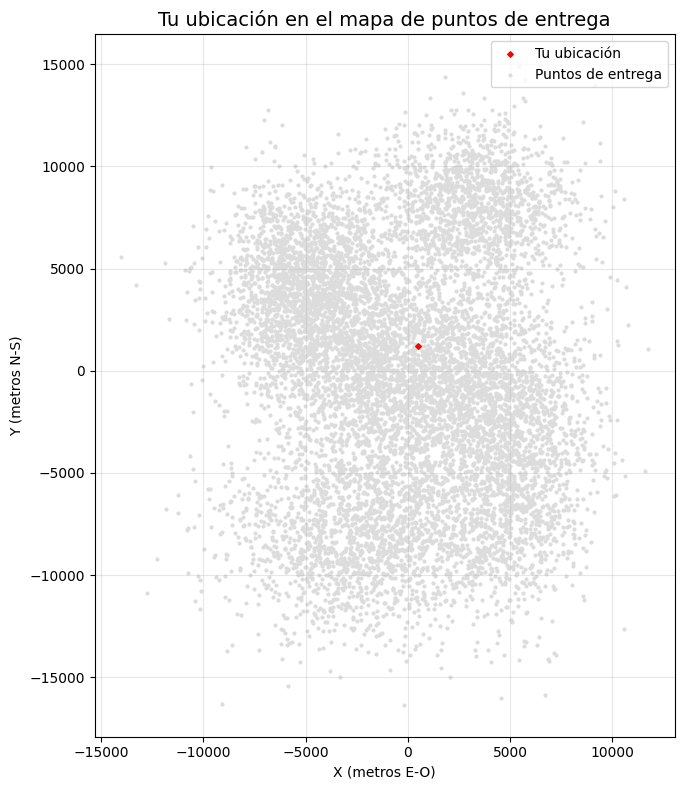

In [69]:
# Visualización del punto de consulta (tu ubicación)
fig, ax = plt.subplots(figsize=(8, 8))
cx, cy = location

# Punto de consulta
ax.scatter([cx], [cy], s=8, color='red', label='Tu ubicación', zorder=6, marker='D')

# Todos los puntos de entrega
ax.scatter(delivery_points[:, 0], delivery_points[:, 1], s=4, color='gainsboro', label='Puntos de entrega')

ax.set_title(f'Tu ubicación en el mapa de puntos de entrega', fontsize=14)
ax.set_xlabel('X (metros E-O)')
ax.set_ylabel('Y (metros N-S)')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Búsqueda del punto de entrega más cercano

In [70]:
t0 = time.perf_counter()
index, distance, neighbor = tree.neighbor(location)
t_n = time.perf_counter() - t0

print(f"CONSULTA")
print(f"  Coordenadas ({location[0]:.0f}m, {location[1]:.0f}m)")

print(f"\nRESULTADO")
print(f"  Índice del punto     {index}")
print(f"  Coordenadas          ({neighbor[0]:.1f}m, {neighbor[1]:.1f}m)")
print(f"  Distancia            {distance:.2f}m")
print(f"  Tiempo de búsqueda   {t_n*1000:.4f}ms")

CONSULTA
  Coordenadas (500m, 1200m)

RESULTADO
  Índice del punto     1632
  Coordenadas          (504.3m, 1155.8m)
  Distancia            44.44m
  Tiempo de búsqueda   0.9790ms


#### Visualización del punto de entrega más cercano

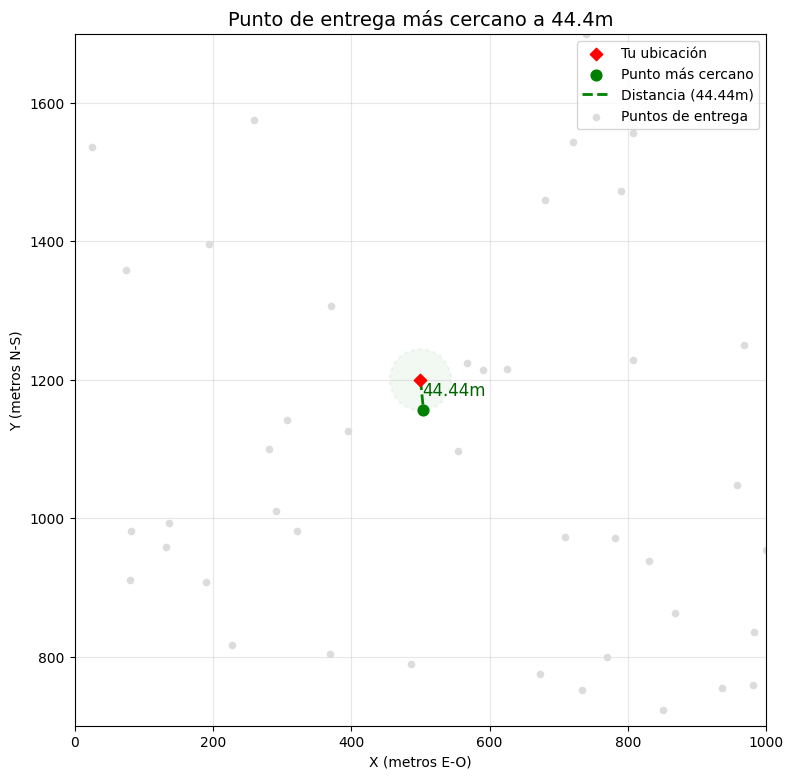

In [71]:
# Visualización del punto más cercano
fig, ax = plt.subplots(figsize=(8, 8))

# Rango de visualización (zoom al área de interés)
margen = 500
cx, cy = location
ax.set_xlim(cx - margen, cx + margen)
ax.set_ylim(cy - margen, cy + margen)

# Punto de consulta
ax.scatter([cx], [cy], s=40, color='red', label='Tu ubicación', zorder=6, marker='D')

# Punto más cercano
ax.scatter([neighbor[0]], [neighbor[1]], s=60, color='green', label=f'Punto más cercano', zorder=5)

# Distancia al punto más cecano
ax.plot([cx, neighbor[0]], [cy, neighbor[1]], color='green', linewidth=2, linestyle='--', zorder=4, label=f'Distancia ({distance:.2f}m)')

# Radio al punto más cercano
ax.add_patch(plt.Circle((cx, cy), distance, fill=True, facecolor='green', alpha=0.05, edgecolor='green', linewidth=2, linestyle=':', zorder=3))

# Anotación de distancia
mid_x = (cx + neighbor[0]) / 2
mid_y = (cy + neighbor[1]) / 2
ax.annotate(f'{distance:.2f}m', xy=(mid_x, mid_y), fontsize=12, color='darkgreen', xytext=(mid_x, mid_y))

# Todos los puntos
ax.scatter(delivery_points[:, 0], delivery_points[:, 1], s=20, color='gainsboro', label='Puntos de entrega', zorder=2)

ax.set_title(f'Punto de entrega más cercano a {distance:.1f}m', fontsize=14)
ax.set_xlabel('X (metros E-O)')
ax.set_ylabel('Y (metros N-S)')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Búsqueda de los puntos de entrega cercanos dentro de un radio

A continuación define el radio en el cual deseas realizar la búsqueda.

In [72]:
default = 500

print(f"Tu ubicación es: ({location[0]:.0f}m, {location[1]:.0f}m)")

radio = input(f"\nIngresa el radio para buscar (por defecto {default}m): ")
radio = radio if radio else default

Tu ubicación es: (500m, 1200m)

Ingresa el radio para buscar (por defecto 500m): 


Realiza la búsqueda de los puntos de entrega más cercanos dentro del radio definido.

In [73]:
t0 = time.perf_counter()
nearby = tree.nearby(location, radio)
t_r = time.perf_counter() - t0

print(f"CONSULTA")
print(f"  Coordenadas ({location[0]:.0f}m, {location[1]:.0f}m)")
print(f"  Radio       {radio}m")

print(f"\nRESULTADO")
print(f"  Puntos encontrados  {len(nearby)}")
print(f"  Tiempo de búsqueda  {t_r*1000:.4f} ms")
if nearby:
    print(f"\n  Los 3 puntos de entrega más cercanos:")
    print(f"  {'Índice':<8}  {'X (m)':<10}  {'Y (m)':<10}  {'Distance (m)':<10}")
    print(f"  {'-'*46}")
    for i, (idx, dist, p) in enumerate(nearby[:3]):
        print(f"  {idx:<8}  {p[0]:<10.2f}  {p[1]:<10.2f}  {dist:<10.2f}")

CONSULTA
  Coordenadas (500m, 1200m)
  Radio       500m

RESULTADO
  Puntos encontrados  34
  Tiempo de búsqueda  0.7330 ms

  Los 3 puntos de entrega más cercanos:
  Índice    X (m)       Y (m)       Distance (m)
  ----------------------------------------------
  1632      504.32      1155.77     44.44     
  311       566.71      1224.43     71.04     
  2361      590.21      1214.43     91.36     


#### Visualización de los puntos de entrega cercanos

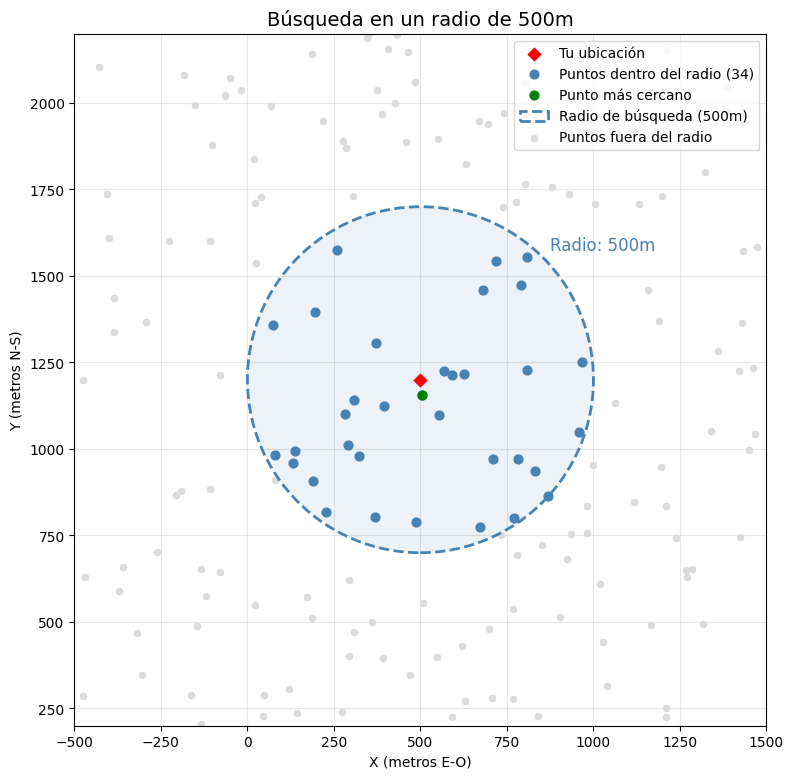

In [74]:
# Visualización de los puntos dentro de un radio
fig, ax = plt.subplots(figsize=(8, 8))

nearby_coords = np.array([v[2] for v in nearby]) if nearby else np.empty((0, 2))

# Rango de visualización (zoom al área de interés)
margen = 1000
cx, cy = location
ax.set_xlim(cx - margen, cx + margen)
ax.set_ylim(cy - margen, cy + margen)

# Punto de consulta
ax.scatter([cx], [cy], s=40, color='red', label='Tu ubicación', zorder=6, marker='D')

# Puntos dentro del radio
if len(nearby_coords) > 0:
  ax.scatter(nearby_coords[:, 0], nearby_coords[:, 1], s=40, color='steelblue', label=f'Puntos dentro del radio ({len(nearby)})', zorder=4)

# Punto más cercano
ax.scatter([neighbor[0]], [neighbor[1]], s=40, color='green', label=f'Punto más cercano', zorder=5)

# Radio de búsqueda
ax.add_patch(plt.Circle((cx, cy), radio, fill=True, facecolor='steelblue', alpha=0.1, zorder=3))
ax.add_patch(plt.Circle((cx, cy), radio, fill=False, edgecolor='steelblue', linewidth=2, linestyle='--', label=f'Radio de búsqueda ({radio}m)', zorder=3))

# Anotación del radio
ax.annotate(f'Radio: {radio}m', xy=(cx + radio*0.75, cy + radio*0.75), fontsize=12, color='steelblue', xytext=(cx + radio*0.75, cy + radio*0.75))

# Puntos fuera del radio
inside = np.zeros(len(delivery_points), dtype=bool)
if len(nearby) > 0:
  idx_inside = [v[0] for v in nearby]
  inside[idx_inside] = True
ax.scatter(delivery_points[~inside, 0], delivery_points[~inside, 1], s=20, color='gainsboro', label='Puntos fuera del radio', zorder=2)

ax.set_title(f'Búsqueda en un radio de {radio}m', fontsize=14)
ax.set_xlabel('X (metros E-O)')
ax.set_ylabel('Y (metros N-S)')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Implementación con listas



La implementación de listas o fuerza bruta revisa todos los puntos para cada consulta, es una búsqueda lineal, por lo que tiene complejidad $O(n)$ en cada búsqueda.

In [75]:
class Force:

  def __init__(self):
    self.points = None


  def build(self, points: np.ndarray) -> None:
    self.points = points


  def neighbor(self, coordinates: np.ndarray) -> Tuple[int, float, np.ndarray]:
    distance = math.inf
    index = -1
    for i, point in enumerate(self.points):
      dist = math.sqrt(sum((a - b)**2 for a, b in zip(coordinates, point)))
      if dist < distance:
        distance = dist
        index = i

    return index, distance, self.points[index]


  def nearby(self, coordinates: np.ndarray, radio: float) -> List[Tuple[int, float, np.ndarray]]:
    results = []
    for i, point in enumerate(self.points):
      distance = math.sqrt(sum((a - b)**2 for a, b in zip(coordinates, point)))
      if distance <= radio:
        results.append((i, distance, point))
      results.sort(key=lambda x: x[1])

    return results


### Construcción de las estructuras de lista

In [76]:
# Estructuras de lista
force = Force()

t0 = time.perf_counter()
force.build(delivery_points)
t_f = time.perf_counter() - t0

print(f"Tiempo de construcción  {t_f*1000:.2f}ms")
print(f"* Solo alamcena una estructura de lista (array)")

Tiempo de construcción  0.12ms
* Solo alamcena una estructura de lista (array)


## Verificación de resultados

La verificación comprueba que los resultados obtenidos en cada consulta (del punto más cercano y los puntos dentro de un radio) coincidan en ambas implementaciones, como Árbol KD y listas o fuerza bruta.

In [77]:
fb_index, fb_distance, fb_point = force.neighbor(location)
fb_nearby = force.nearby(location, radio)

print(f"\nVERIFICACIÓN DE RESULTADOS")
print(f"  Búsqueda del punto más cercano (vecino)")
print(f"    {'Método':<16}  {'Índice':<8} {'Distance (m)':>10}")
print(f"    {'-'*40}")
print(f"    {'Quad Tree':<16}  {index:<8}  {distance:>10.2f}m")
print(f"    {'Fuerza Bruta':<16}  {fb_index:<8}  {fb_distance:>10.2f}m")
print(f"  RESULTADO: {'Coinciden' if index == fb_index else 'No coinciden'}")

print(f"\n  Búsqueda de puntos dentro del radio")
print(f"    Quad Tree       {len(nearby)} puntos")
print(f"    Fuerza Bruta  {len(fb_nearby)} puntos")
print(f"  RESULTADO: {'Coinciden' if len(nearby) == len(fb_nearby) else 'No coinciden'}")


VERIFICACIÓN DE RESULTADOS
  Búsqueda del punto más cercano (vecino)
    Método            Índice   Distance (m)
    ----------------------------------------
    Quad Tree         1632           44.44m
    Fuerza Bruta      1632           44.44m
  RESULTADO: Coinciden

  Búsqueda de puntos dentro del radio
    Quad Tree       34 puntos
    Fuerza Bruta  34 puntos
  RESULTADO: Coinciden


## Análisis de rendimiento

La comparación de rendimiento se realiza entre el Quad Tree y la fuerza bruta con listas para diferentes tamaños de datos.

### Benchmark

In [78]:
QUERIES = 50 # Consultas aleatorias por tamaño
REPETITIONS = 1 # Repeticiones
sizes = [100, 500, 1000, 5000, 10000] # Tamaños
benchmark = {'size': [], 't_kd_f': [], 't_kd_n': [], 't_kd_r': [], 't_fb_n': [], 't_fb_r': [], 'speed_n': [], 'speed_r': []}

print(f"{'Tamaño':>8} | {'Quad Vecino (ms)':>14} | {'List Vecino (ms)':>16} | {'SpeedUp Vecino':>15} | {'Quad Radio (ms)':>14} | {'List Radio (ms)':>16} | {'SpeedUp Radio':>15}")
print("-" * 118)

for n in sizes:
  # Tomar subconjunto de puntos y sus límites
  bench_points = delivery_points[:n].copy()
  bench_min = bench_points.min(axis=0)
  bench_max = bench_points.max(axis=0)

  # Consultas aleatorias dentro del rango de datos
  queries = np.random.uniform(-10000, 10000, (QUERIES, 2))

  # Quad Tree
  bench_tree = QuadTree(bench_min, bench_max)
  t0 = time.perf_counter()
  for _ in range(REPETITIONS):
    bench_tree.build(bench_points)
  t_kd_f = (time.perf_counter() - t0) / REPETITIONS * 1000

  t0 = time.perf_counter()
  for q in queries:
    bench_tree.neighbor(q)
  t_kd_n = (time.perf_counter() - t0) / QUERIES * 1000

  t0 = time.perf_counter()
  for q in queries:
    bench_tree.nearby(q, radio)
  t_kd_r = (time.perf_counter() - t0) / QUERIES * 1000

  # Listas o fuerza bruta
  bench_force = Force()
  bench_force.build(bench_points)

  t0 = time.perf_counter()
  for q in queries:
    bench_force.neighbor(q)
  t_fb_n = (time.perf_counter() - t0) / QUERIES * 1000

  t0 = time.perf_counter()
  for q in queries:
    bench_force.nearby(q, radio)
  t_fb_r = (time.perf_counter() - t0) / REPETITIONS * 1000

  # SpeedUp
  speedup_n = t_fb_n / t_kd_n if t_kd_n > 0 else 0
  speedup_r = t_fb_r / t_kd_r if t_kd_r > 0 else 0

  benchmark['size'].append(n)
  benchmark['t_kd_f'].append(t_kd_f)
  benchmark['t_kd_n'].append(t_kd_n)
  benchmark['t_kd_r'].append(t_kd_r)
  benchmark['t_fb_n'].append(t_fb_n)
  benchmark['t_fb_r'].append(t_fb_r)
  benchmark['speed_n'].append(speedup_n)
  benchmark['speed_r'].append(speedup_r)

  print(f"{n:>8,} | {t_kd_n:>12.4f}ms | {t_fb_n:>14.4f}ms | {speedup_n:>14.2f}x | {t_kd_r:>12.4f}ms | {t_fb_r:>14.4f}ms | {speedup_r:>14.2f}x")

  Tamaño | Quad Vecino (ms) | List Vecino (ms) |  SpeedUp Vecino | Quad Radio (ms) |  List Radio (ms) |   SpeedUp Radio
----------------------------------------------------------------------------------------------------------------------
     100 |       0.0359ms |         0.2695ms |           7.51x |       0.0174ms |        10.1841ms |         584.38x
     500 |       0.0546ms |         0.9675ms |          17.72x |       0.0372ms |        51.8774ms |        1393.15x
   1,000 |       0.0621ms |         1.8293ms |          29.44x |       0.0959ms |       106.6183ms |        1112.04x
   5,000 |       0.0926ms |         9.1628ms |          98.96x |       0.1838ms |       559.2866ms |        3043.49x
  10,000 |       0.0920ms |        18.4128ms |         200.09x |       0.3350ms |      1388.9766ms |        4146.74x


### Visualización del benchmark

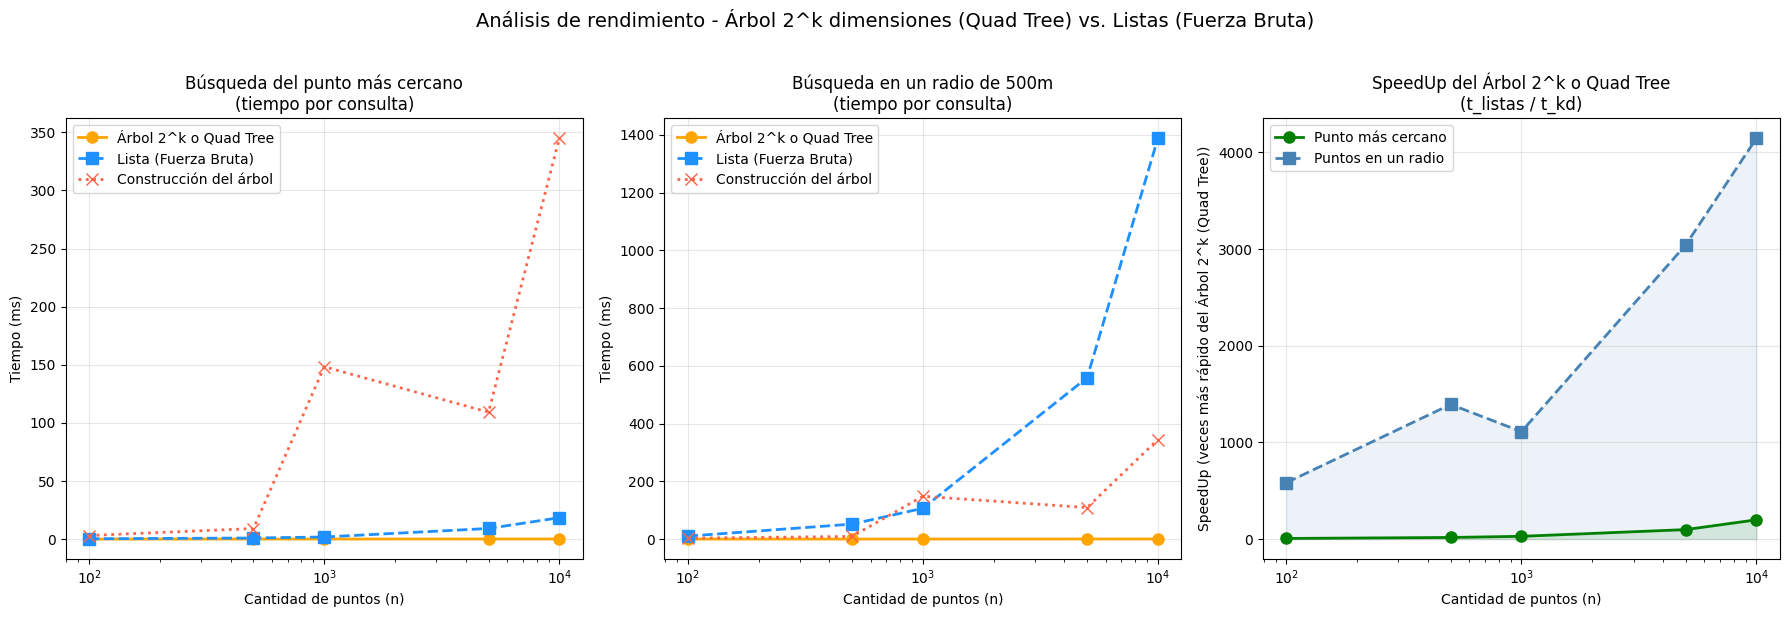

In [79]:
# Visualización del benchmark
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Búsqueda del punto más cercano
ax = axes[0]
ax.plot(benchmark['size'], benchmark['t_kd_n'], 'o-', color='orange', label='Árbol 2^k o Quad Tree', linewidth=2, markersize=8)
ax.plot(benchmark['size'], benchmark['t_fb_n'], 's--', color='dodgerblue', label='Lista (Fuerza Bruta)', linewidth=2, markersize=8)
ax.plot(benchmark['size'], benchmark['t_kd_f'], 'x:', color='tomato', label='Construcción del árbol', linewidth=2, markersize=8)
ax.set_title('Búsqueda del punto más cercano\n(tiempo por consulta)', fontsize=12)
ax.set_xlabel('Cantidad de puntos (n)')
ax.set_ylabel('Tiempo (ms)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# Búsqueda en un radio
ax = axes[1]
ax.plot(benchmark['size'], benchmark['t_kd_r'], 'o-', color='orange', label='Árbol 2^k o Quad Tree', linewidth=2, markersize=8)
ax.plot(benchmark['size'], benchmark['t_fb_r'], 's--', color='dodgerblue', label='Lista (Fuerza Bruta)', linewidth=2, markersize=8)
ax.plot(benchmark['size'], benchmark['t_kd_f'], 'x:', color='tomato', label='Construcción del árbol', linewidth=2, markersize=8)
ax.set_title(f'Búsqueda en un radio de {radio}m\n(tiempo por consulta)', fontsize=12)
ax.set_xlabel('Cantidad de puntos (n)')
ax.set_ylabel('Tiempo (ms)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# Speedup
ax = axes[2]
ax.plot(benchmark['size'], benchmark['speed_n'], 'o-', color='green', label='Punto más cercano', linewidth=2, markersize=8)
ax.plot(benchmark['size'], benchmark['speed_r'],  's--', color='steelblue', label='Puntos en un radio', linewidth=2, markersize=8)
ax.fill_between(benchmark['size'], 1, benchmark['speed_r'], alpha=0.1, color='steelblue')
ax.fill_between(benchmark['size'], 1, benchmark['speed_n'], alpha=0.1, color='green')
ax.set_title('SpeedUp del Árbol 2^k o Quad Tree\n(t_listas / t_kd)', fontsize=12)
ax.set_xlabel('Cantidad de puntos (n)')
ax.set_ylabel('SpeedUp (veces más rápido del Árbol 2^k (Quad Tree))')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.suptitle('Análisis de rendimiento - Árbol 2^k dimensiones (Quad Tree) vs. Listas (Fuerza Bruta)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Conclusiones

Los resultados muestran que el tiempo de consulta en el Quad Tree se comportan con una complejidad logarítmica $O(\log n)$ incluso cuando $n$ aumenta de magnitud; mientras que la búsqueda lineal en listas obliga a realizar una comparación $O(n)$ para cada consulta.

Aunque la construcción del árbol tiene un costo superior a la simple inserción en una lista, la intersección de las curvas de rendimiento demuestra que tras varias consultas el costo acumulado de la búsqueda lineal supera la inversión inicial de construcción.

El SpeedUp está favor del Quad Tree, particularmente pronunciado en la búsqueda por radio; esto se debe a que el algoritmo de búsqueda en el árbol puede determinar rápidamente si un nodo y todos sus hijos quedan por fuera del radio de búsqueda mediante una comparación de límites de la caja sin calcular distancias individuales para cada punto. Las fluctuaciones observadas en el SpeedUp sugieren sensibilidad a la densidad y/o distribución de los datos en el espacio, donde la profundidad del árbol impacta directamente en la cantidad de nodos visitados.

La diferecnia entre las latencias entre Fuerza Bruta y Quad Tree es determinante para la viabilidad de aplicaciones de tipo geográficas o de simulación.